In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [2]:
df = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\acidentes_pbic_somas.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df.shape)



Shape inicial: (1678326, 53)


In [3]:
df["severity_index"] = (
    4 * df["Sum_Mortos"] +
    2 * df["Sum_Feridos_Graves"] +
    1 * df["Sum_Feridos_Leves"]
)

# --- Target transformada para ML ---
df["severity_index_log"] = np.log1p(df["severity_index"])


df["km"] = (
    df["km"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["km"] = pd.to_numeric(df["km"], errors="coerce")

df = df.dropna(subset=["km"])



In [4]:
df["km_bin"] = (df["km"] // 5) * 5   # segmentos de 5 km

df_segmento = df.groupby(["br", "uf", "km_bin"]).agg({
    "severity_index": "mean",
    "id": "count"
}).reset_index()

df_segmento.rename(columns={"id": "n_acidentes"}, inplace=True)

df_segmento["score_risco"] = ( df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"]))

df_segmento = df_segmento.sort_values("score_risco", ascending=False)

In [5]:
df["severity_log"] = np.log1p(df["severity_index"])

df = df[df["severity_index"] >= 0]

df["idade_veiculo"] = 2025 - df["ano_fabricacao_veiculo"]

df["latitude"] = (
    df["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["longitude"] = (
    df["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

In [6]:
features = [
    "uf",
    "br",
    "km_bin",
    "hora",
    "mes",
    "dia_semana",
    "tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo", #*
    "tipo_veiculo",
    "idade",
    "idade_veiculo",
    'latitude', 
    'longitude',
    'regional', 
    'Fabricante',
    'Modelo'
]

df = df.dropna(subset=["severity_log"])

for col in features:
    
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
        
    else:
        df[col] = df[col].fillna("Desconhecido")


categoricas = df[features].select_dtypes(include="object").columns

for col in categoricas:
    df[col] = df[col].astype("category")

X = df[features]
y = df["severity_log"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

C:\Users\fause\AppData\Local\Temp\ipykernel_6616\2020907497.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df[features].select_dtypes(include="object").columns


In [7]:
import lightgbm as lgb

# modelo = lgb.LGBMRegressor(
#     n_estimators=400,
#     learning_rate=0.05,
#     num_leaves=64,
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     max_bin=512

# )

modelo = lgb.LGBMRegressor(
    n_estimators=800,          # mais árvores
    learning_rate=0.03,        # aprendizado mais suave
    num_leaves=128,            # mais capacidade
    max_depth=-1,              # sem limite explícito
    min_child_samples=40,      # evita overfitting
    subsample=0.8,             # bagging
    colsample_bytree=0.8,      # feature sampling
    reg_alpha=0.5,             # regularização L1
    reg_lambda=0.5,            # regularização L2
    random_state=42,
    n_jobs=-1,
    force_col_wise=True,
    max_bin=512
)

modelo.fit(X_train, y_train)

[LightGBM] [Info] Total Bins 2713
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 20
[LightGBM] [Info] Start training from score 0.582218


,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.03
,n_estimators,800
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,40


In [8]:
# import shap
# import numpy as np

# # pegar amostra aleatória pequena
# X_sample = X_test.sample(5000, random_state=42)

# explainer = shap.TreeExplainer(modelo)
# shap_values = explainer.shap_values(X_sample)

# shap.summary_plot(shap_values, X_sample)

In [9]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

pred = modelo.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.4166924852911023
R2: 0.5147017934271683


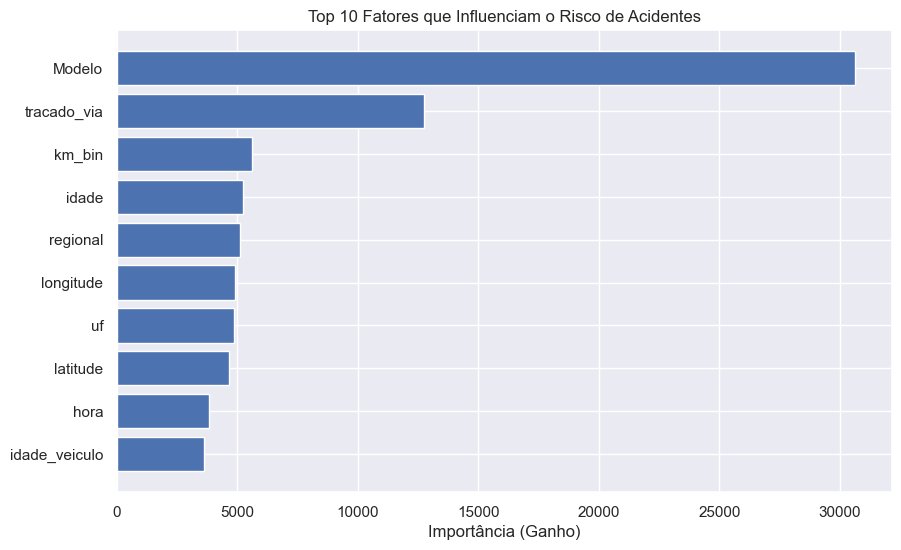

In [10]:
import matplotlib.pyplot as plt

# Pegando a importância das colunas
importancias = pd.DataFrame({
    'feature': X_train.columns,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

# Plotando
plt.figure(figsize=(10, 6))
plt.barh(importancias['feature'][:10], importancias['importancia'][:10])
plt.xlabel("Importância (Ganho)")
plt.title("Top 10 Fatores que Influenciam o Risco de Acidentes")
plt.gca().invert_yaxis()
plt.show()

In [11]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importances)

                   feature  importance
19                  Modelo       30614
10             tracado_via       12744
2                   km_bin        5624
13                   idade        5259
17                regional        5135
16               longitude        4925
0                       uf        4866
15                latitude        4664
3                     hora        3820
14           idade_veiculo        3617
6            tipo_acidente        3572
5               dia_semana        3408
18              Fabricante        2622
1                       br        2616
4                      mes        2611
8   condicao_metereologica        1730
12            tipo_veiculo        1310
11                uso_solo         888
9               tipo_pista         803
7                 fase_dia         772


In [12]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(modelo, X, y, cv=kf, scoring='r2')

print("R2 por fold:", r2_scores)
print("R2 médio:", np.mean(r2_scores))
print("Desvio padrão:", np.std(r2_scores))

rmse_scores = -cross_val_score(modelo, X, y, cv=kf,
                                scoring='neg_root_mean_squared_error')

print("RMSE médio:", np.mean(rmse_scores))

[LightGBM] [Info] Total Bins 2714
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 20
[LightGBM] [Info] Start training from score 0.582218
[LightGBM] [Info] Total Bins 2718
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 20
[LightGBM] [Info] Start training from score 0.582288
[LightGBM] [Info] Total Bins 2726
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 20
[LightGBM] [Info] Start training from score 0.581831
[LightGBM] [Info] Total Bins 2722
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 20
[LightGBM] [Info] Start training from score 0.582085
[LightGBM] [Info] Total Bins 2731
[LightGBM] [Info] Number of data points in the train set: 1140468, number of used features: 20
[LightGBM] [Info] Start training from score 0.581982
R2 por fold: [0.51514152 0.51306567 0.51310703 0.5141422  0.51433607]
R2 médio: 0.51395849

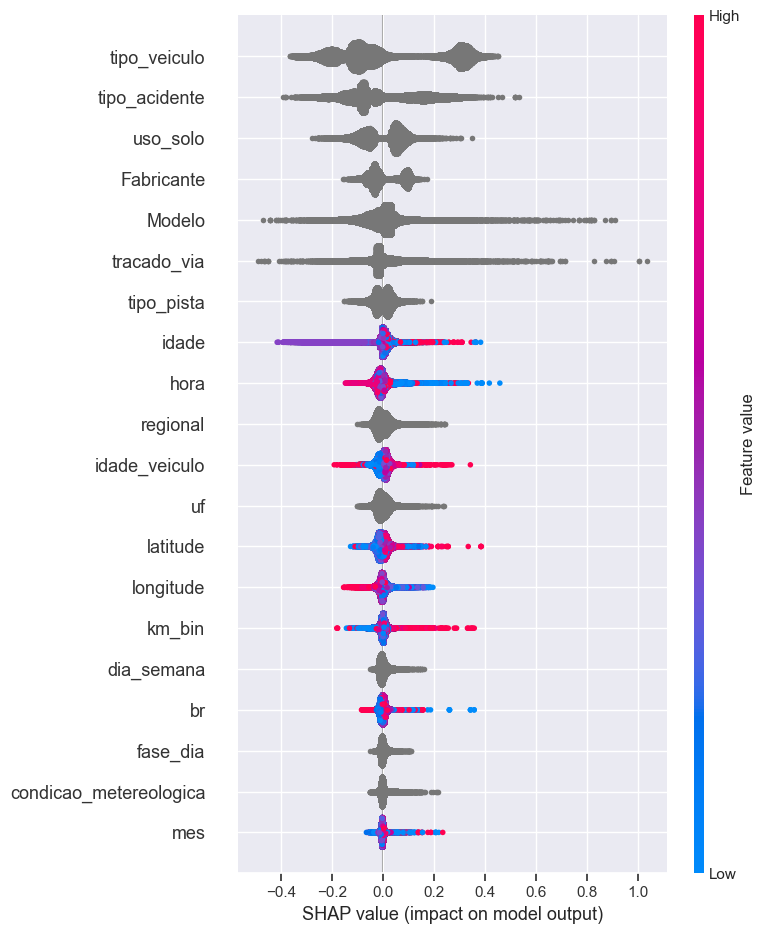

In [13]:
import shap

X_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [14]:
# print("\nSeveridade média por fase do dia:")
# print(df.groupby("fase_dia")["severity_index"].mean())

# print("\nSeveridade média por tipo de pista:")
# print(df.groupby("tipo_pista")["severity_index"].mean())

# print("\nSeveridade média por condição meteorológica:")
# print(df.groupby("condicao_metereologica")["severity_index"].mean())

# print("\nTop 10 tipos de acidente mais severos:")
# print(
#     df.groupby("tipo_acidente")["severity_index"]
#     .mean()
#     .sort_values(ascending=False)
#     .head(10)
# )

In [15]:
print("Linhas atuais:", len(df))

Linhas atuais: 1425585


In [16]:
# =============================
# 📊 Totais gerais
# =============================

total_acidentes = len(df)
total_segmentos = len(df_segmento)

print("Total de acidentes no dataset:", total_acidentes)
print("Total de segmentos analisados:", total_segmentos)

Total de acidentes no dataset: 1425585
Total de segmentos analisados: 12157


In [17]:
print("Shape inicial:", df.shape)

Shape inicial: (1425585, 58)


In [18]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

def rodar_pdp(
    modelo,
    X,
    nome_modelo="Modelo",
    sample_size=None
):
    # se quiser performance
    if sample_size:
        X_plot = X.sample(sample_size, random_state=42)
    else:
        X_plot = X

    features = [
        ("hora", None),
        ("mes", ["mes"] if X["mes"].dtype == "object" else None),
        ("dia_semana", ["dia_semana"]),
        ("idade_veiculo", None),
        ("tipo_pista", ["tipo_pista"]),
        ("fase_dia", ["fase_dia"]),
        ("condicao_metereologica", ["condicao_metereologica"]),
    ]

    for feature, cat in features:
        PartialDependenceDisplay.from_estimator(
            modelo,
            X_plot,
            [feature],
            categorical_features=cat,
            grid_resolution=50 if feature == "idade_veiculo" else 100,
            kind="average"
        )

        plt.title(f"{nome_modelo} - Impacto de {feature}")
        
        if feature == "idade_veiculo":
            plt.xlim(0, 35)

        plt.show()

    # 🔥 análise por clima (interação)
    top_climas = X["condicao_metereologica"].value_counts().head(4).index

    for clima in top_climas:
        subset = X[X["condicao_metereologica"] == clima]

        if sample_size:
            subset = subset.sample(min(sample_size, len(subset)), random_state=42)

        PartialDependenceDisplay.from_estimator(
            modelo,
            subset,
            ["hora"]
        )

        plt.title(f"{nome_modelo} - Risco por hora ({clima})")
        plt.show()

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


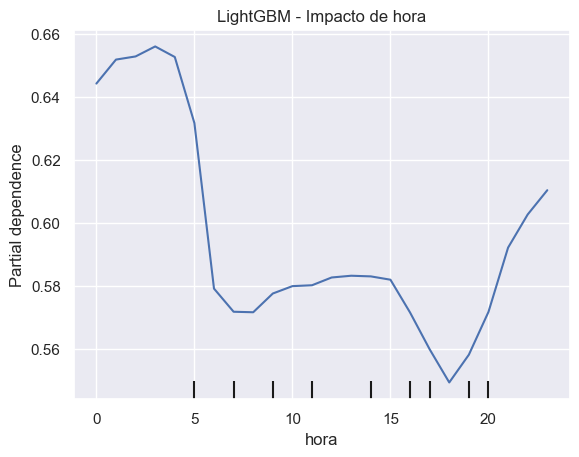

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


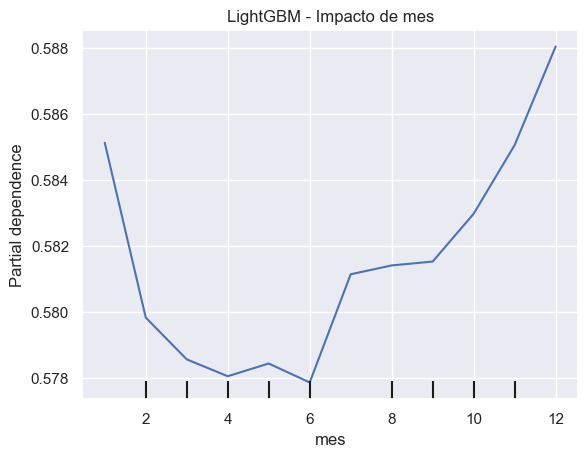

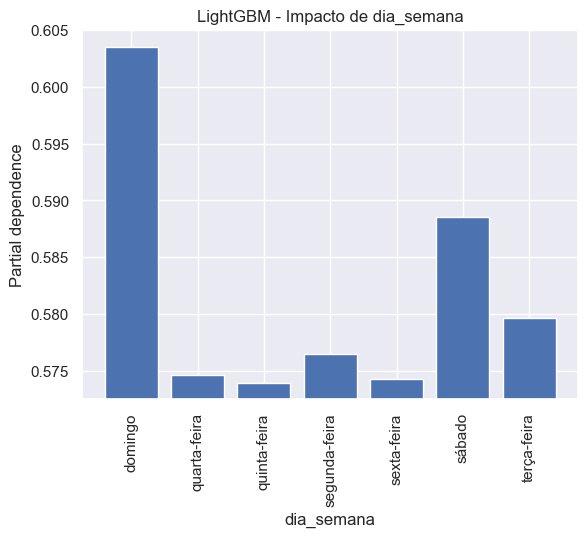

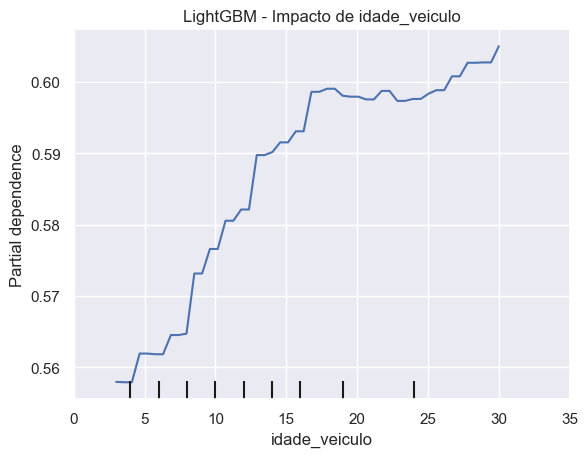

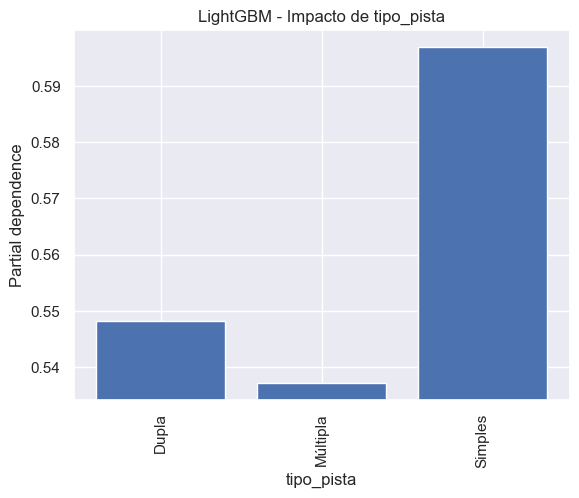

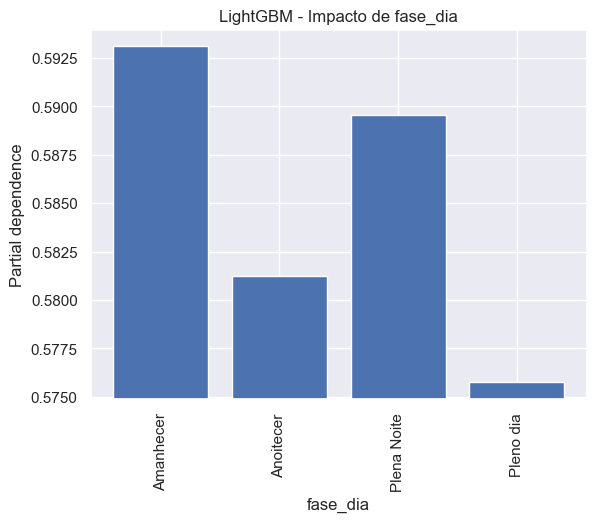

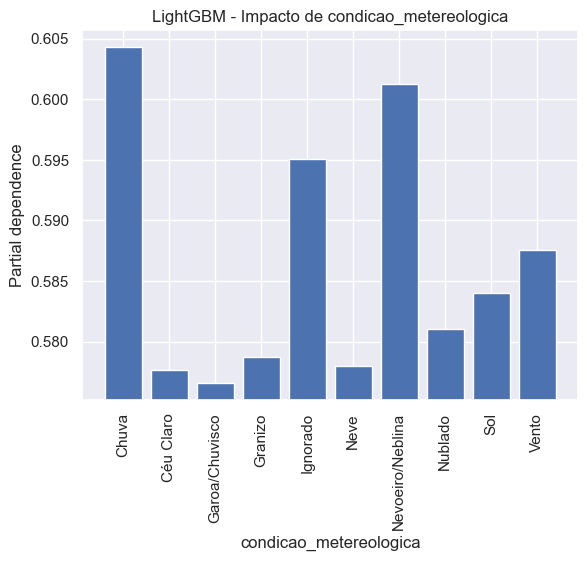

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


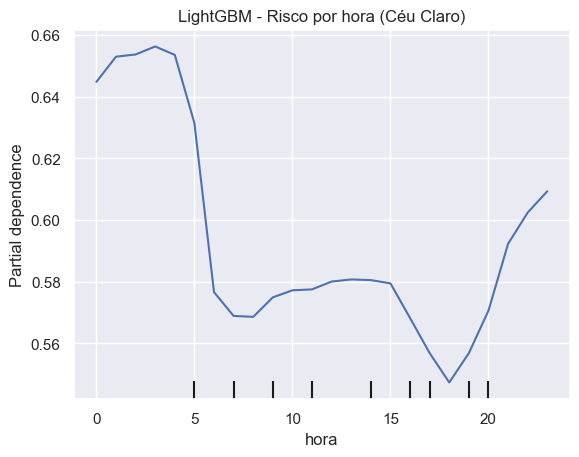

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


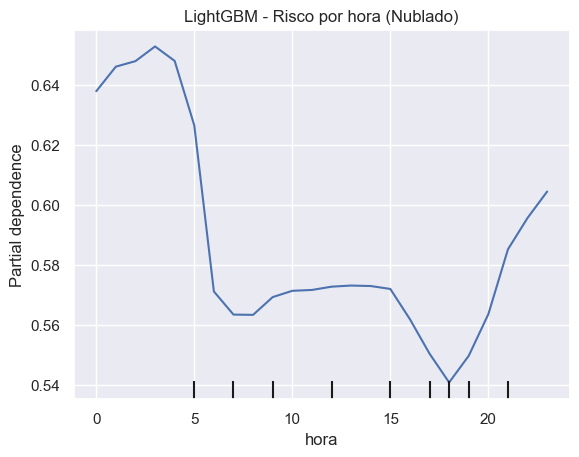

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


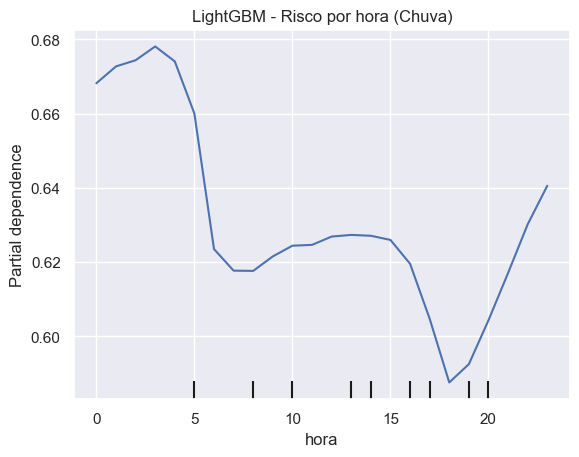

c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


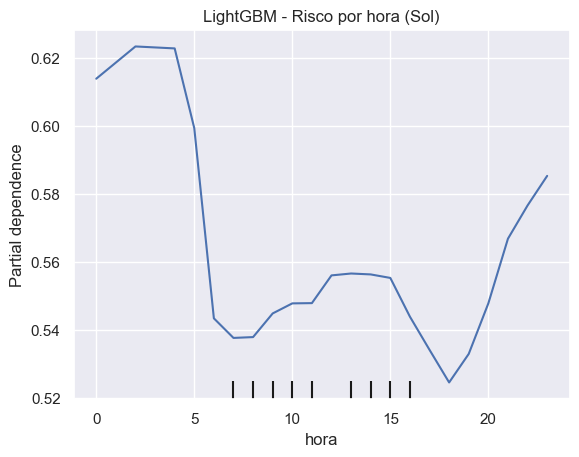

In [19]:
rodar_pdp(modelo, X_test, nome_modelo="LightGBM")

In [23]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

def rodar_pdp_categoricas(
    modelo,
    X,
    nome_modelo="Modelo",
    sample_size=None
):
    # performance
    if sample_size:
        X_plot = X.sample(sample_size, random_state=42)
    else:
        X_plot = X

    # 🔥 novas features categóricas
    features = [
        ("tipo_veiculo", ["tipo_veiculo"]),
        ("tipo_acidente", ["tipo_acidente"]),
        ("uso_solo", ["uso_solo"]),
    ]

    for feature, cat in features:
        PartialDependenceDisplay.from_estimator(
            modelo,
            X_plot,
            [feature],
            categorical_features=cat,
            kind="average"
        )

        plt.title(f"{nome_modelo} - Impacto de {feature}")
        plt.ylabel("Probabilidade de Acidente Grave")

        plt.xticks(rotation=45)  # 🔥 melhora visual
        plt.tight_layout()

        plt.show()

    # 🔥 análise cruzada: tipo_veiculo vs hora
    top_veiculos = X["tipo_veiculo"].value_counts().head(4).index

    for veic in top_veiculos:
        subset = X[X["tipo_veiculo"] == veic]

        if sample_size:
            subset = subset.sample(min(sample_size, len(subset)), random_state=42)

        PartialDependenceDisplay.from_estimator(
            modelo,
            subset,
            ["hora"]
        )

        plt.title(f"{nome_modelo} - Risco por hora ({veic})")
        plt.ylabel("Probabilidade de Acidente Grave")

        plt.show()